In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.model_selection import GridSearchCV, KFold, cross_val_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

In [2]:
data_recovery_train=pd.read_csv("/datasets/gold_recovery_train.csv")

data_recovery_test=pd.read_csv("/datasets/gold_recovery_test.csv")

data_recovery_full=pd.read_csv("/datasets/gold_recovery_full.csv")

In [34]:
files = [data_recovery_train, data_recovery_test, data_recovery_full]

for file in files:
    print("Archivo contiene:\n")
    file.info()
    print("\n\n\n")
    print(file.head())
    print("\n\n\n")

Archivo contiene:

<class 'pandas.core.frame.DataFrame'>
Int64Index: 13789 entries, 0 to 16859
Data columns (total 89 columns):
 #   Column                                              Non-Null Count  Dtype         
---  ------                                              --------------  -----         
 0   date                                                13789 non-null  datetime64[ns]
 1   final.output.concentrate_ag                         13789 non-null  float64       
 2   final.output.concentrate_pb                         13789 non-null  float64       
 3   final.output.concentrate_sol                        13789 non-null  float64       
 4   final.output.concentrate_au                         13789 non-null  float64       
 5   final.output.recovery                               13789 non-null  float64       
 6   final.output.tail_ag                                13789 non-null  float64       
 7   final.output.tail_pb                                13789 non-null  float64

In [4]:
train = pd.read_csv("/datasets/gold_recovery_train.csv")

F = train['rougher.input.feed_au']
C = train['rougher.output.concentrate_au']
T = train['rougher.output.tail_au']

# Se calcula la recuperación manual
recovery_calc = (C * (F - T)) / (F * (C - T)) * 100

# Se compara contra la columna original
recovery_real = train['rougher.output.recovery']

# EAM (Error Absoluto Medio)
mae = mean_absolute_error(recovery_real.dropna(), recovery_calc[recovery_real.notna()])

print("EAM entre recuperación calculada y la del dataset:", mae)

EAM entre recuperación calculada y la del dataset: 9.303415616264301e-15


In [5]:
train_cols = set(data_recovery_train.columns)
test_cols = set(data_recovery_test.columns)

missing_cols = train_cols - test_cols
missing_cols

{'final.output.concentrate_ag',
 'final.output.concentrate_au',
 'final.output.concentrate_pb',
 'final.output.concentrate_sol',
 'final.output.recovery',
 'final.output.tail_ag',
 'final.output.tail_au',
 'final.output.tail_pb',
 'final.output.tail_sol',
 'primary_cleaner.output.concentrate_ag',
 'primary_cleaner.output.concentrate_au',
 'primary_cleaner.output.concentrate_pb',
 'primary_cleaner.output.concentrate_sol',
 'primary_cleaner.output.tail_ag',
 'primary_cleaner.output.tail_au',
 'primary_cleaner.output.tail_pb',
 'primary_cleaner.output.tail_sol',
 'rougher.calculation.au_pb_ratio',
 'rougher.calculation.floatbank10_sulfate_to_au_feed',
 'rougher.calculation.floatbank11_sulfate_to_au_feed',
 'rougher.calculation.sulfate_to_au_concentrate',
 'rougher.output.concentrate_ag',
 'rougher.output.concentrate_au',
 'rougher.output.concentrate_pb',
 'rougher.output.concentrate_sol',
 'rougher.output.recovery',
 'rougher.output.tail_ag',
 'rougher.output.tail_au',
 'rougher.output.ta

## Columnas del data set 

Al comparar las columnas del conjunto de entrenamiento y del conjunto de prueba, se identificaron 34 características presentes únicamente en el conjunto de entrenamiento. Estas variables corresponden principalmente a salidas del proceso (outputs) de distintas etapas de flotación: rougher, primary cleaner, secondary cleaner y final.

Además, se incluyen las dos variables objetivo requeridas para el modelado (rougher.output.recovery y final.output.recovery) y varias características derivadas calculadas por la planta (rougher.calculation.*).

Esto es coherente, pues el conjunto de prueba solo debe contener características disponibles antes de realizar la predicción, siendo todas las columnas excluidas de tipo float64.

## Conversión de fechas

Primero, convertimos la columna `date` de los conjuntos de datos a tipo `datetime` para facilitar su manipulación y análisis temporal:

In [6]:
data_recovery_train['date'] = pd.to_datetime(data_recovery_train['date'])
data_recovery_test['date']  = pd.to_datetime(data_recovery_test['date'])
data_recovery_full['date']  = pd.to_datetime(data_recovery_full['date'])

## Eliminación de filas con valores nulos en las columnas objetivo

Para asegurar la calidad de los datos de entrenamiento, eliminamos las filas donde falte alguno de los valores de recuperación que vamos a predecir:

In [7]:
target_cols = ['rougher.output.recovery', 'final.output.recovery']

data_recovery_train = data_recovery_train.dropna(subset=target_cols)

## Interpolación y relleno de valores faltantes

Para garantizar que no queden valores faltantes en los conjuntos de entrenamiento y prueba, aplicamos interpolación lineal y luego rellenamos los posibles valores restantes hacia adelante y hacia atrás:

In [8]:
data_recovery_train = data_recovery_train.interpolate(method='linear')
data_recovery_train = data_recovery_train.fillna(method='ffill').fillna(method='bfill')

data_recovery_test = data_recovery_test.interpolate(method='linear')
data_recovery_test = data_recovery_test.fillna(method='ffill').fillna(method='bfill')

## Definición de las variables objetivo

Para entrenar los modelos, definimos las columnas de recuperación como nuestras variables objetivo:

In [9]:
y_rougher = data_recovery_train['rougher.output.recovery']
y_final   = data_recovery_train['final.output.recovery']

common_cols = X_train.columns.intersection(X_test.columns)
X_train = X_train[common_cols]
X_test  = X_test[common_cols]

print("X_train shape after alignment:", X_train.shape)
print("X_test shape after alignment:", X_test.shape)

## Análisis de los datos

### 1. Concentración de metales según la etapa de purificación

Observamos cómo cambian las concentraciones de oro (Au), plata (Ag) y plomo (Pb) en las diferentes etapas: materia prima, concentrado rougher y concentrado final.


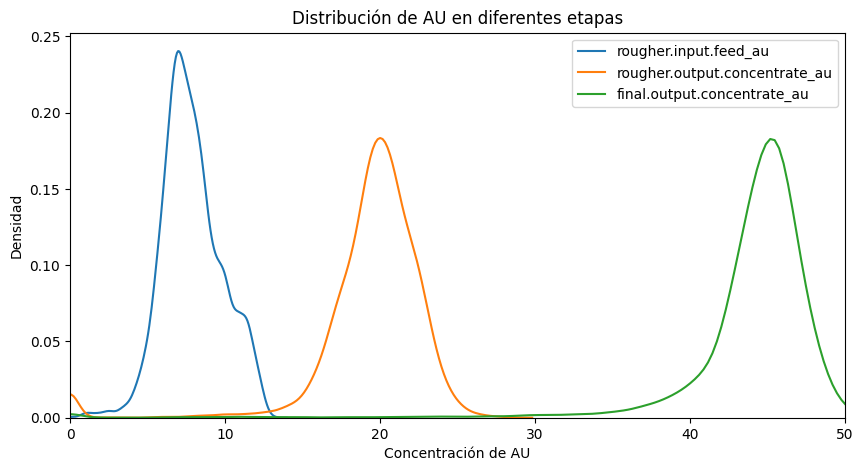

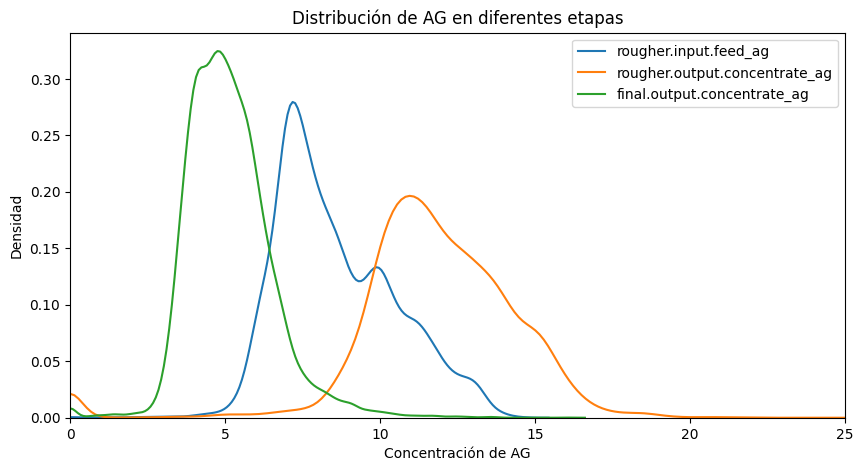

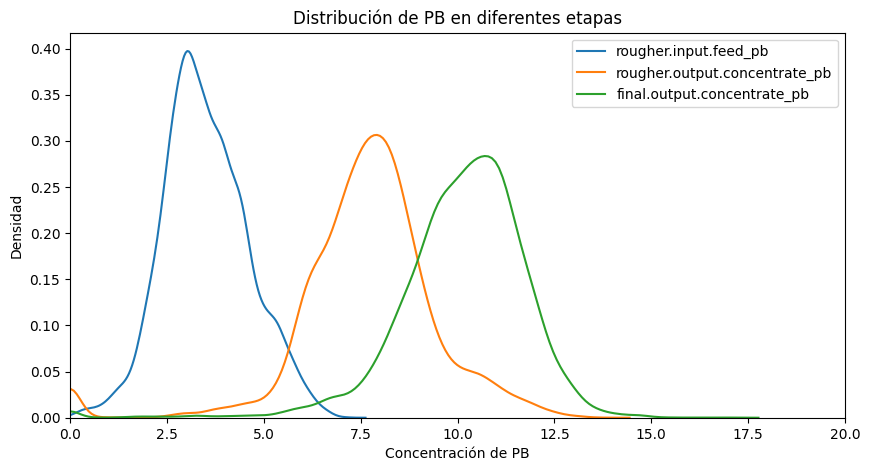

In [10]:
metal_cols = ['au', 'ag', 'pb']
stages = ['feed', 'rougher.output.concentrate', 'final.output.concentrate']


metal_cols = ['au', 'ag', 'pb']
stages = ['rougher.input.feed', 'rougher.output.concentrate', 'final.output.concentrate']

limits = {'au': (0, 50), 'ag': (0, 25), 'pb': (0, 20)}  # límites para eje X

for metal in metal_cols:
    plt.figure(figsize=(10, 5))
    found = False
    for stage in stages:
        col_matches = [col for col in data_recovery_train.columns if stage in col and metal in col]
        for col_name in col_matches:
            sns.kdeplot(data=data_recovery_train[col_name], label=col_name)
            found = True
    if found:
        plt.title(f'Distribución de {metal.upper()} en diferentes etapas')
        plt.xlabel(f'Concentración de {metal.upper()}')
        plt.ylabel('Densidad')
        plt.xlim(limits[metal])  # limita el eje X para mejor visualización
        plt.legend()
        plt.show()
    else:
        print(f"No se encontraron columnas para {metal}")

# Análisis de concentración de metales en diferentes etapas

Se analizaron las distribuciones de concentración de Au, Ag y Pb en tres etapas clave del proceso de purificación: alimentación (feed), concentrado rougher y concentrado final.

- **Oro (Au):**  
  La concentración de Au presenta un desplazamiento claro entre etapas, mostrando que el concentrado final tiene las mayores concentraciones, seguido del concentrado rougher y finalmente la alimentación, que tiene concentraciones mucho menores y más dispersas.

- **Plata (Ag):**  
  La distribución de Ag también cambia notablemente entre etapas. La alimentación tiene un pico más pronunciado en concentraciones bajas, mientras que el concentrado rougher y el concentrado final muestran picos desplazados hacia concentraciones mayores, indicando un proceso efectivo de concentración.

- **Plomo (Pb):**  
  Similarmente, Pb muestra un patrón de concentración creciente a medida que avanza el proceso, con la alimentación en concentraciones bajas y los concentrados rougher y final en concentraciones más altas y definidas.

Esta visualización confirma que el proceso de purificación está funcionando correctamente, concentrando los metales a lo largo de las etapas. Además, no se observan valores extremos o distribuciones anómalas que puedan afectar la calidad del modelo.

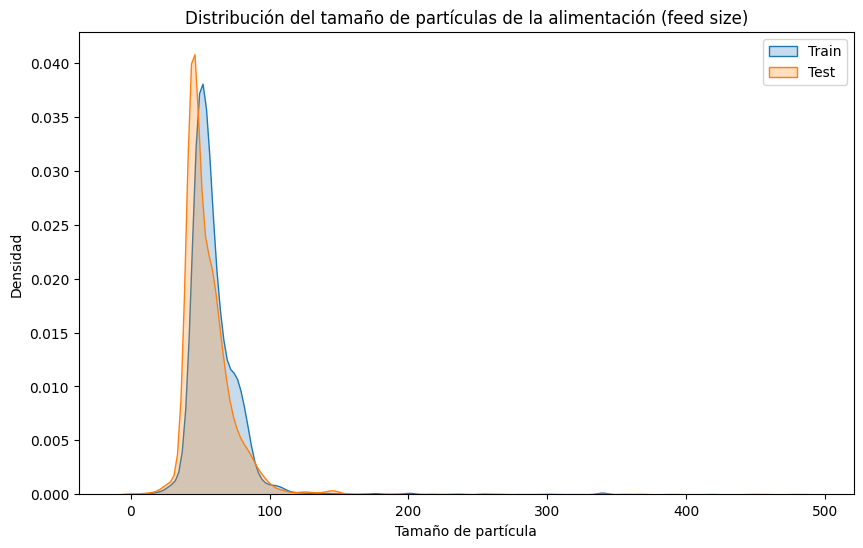

In [11]:
plt.figure(figsize=(10,6))
sns.kdeplot(data_recovery_train['rougher.input.feed_size'], label='Train', shade=True)
sns.kdeplot(data_recovery_test['rougher.input.feed_size'], label='Test', shade=True)
plt.title('Distribución del tamaño de partículas de la alimentación (feed size)')
plt.xlabel('Tamaño de partícula')
plt.ylabel('Densidad')
plt.legend()
plt.show()

## Comparación del tamaño de partículas en alimentación entre conjunto de entrenamiento y prueba

Se compararon las distribuciones del tamaño de las partículas en la alimentación (`rougher.input.feed_size`) para los conjuntos de entrenamiento y prueba mediante una gráfica de densidad.

Como se observa en la gráfica, las distribuciones de tamaño de partículas en ambos conjuntos son muy similares, con picos casi superpuestos y formas de distribución parecidas. Esto indica que no hay una diferencia significativa en las características de tamaño de partícula entre los datos de entrenamiento y prueba.

Esta similitud es favorable, ya que sugiere que el modelo podrá generalizar adecuadamente sobre el conjunto de prueba sin sesgos importantes debido a diferencias en la distribución de esta característica.

 No se encontraron columnas para la etapa feed


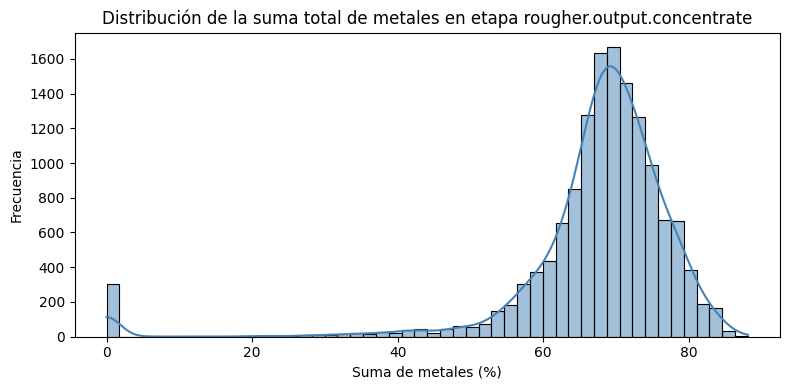


📊 Estadísticas de la suma total de metales en etapa rougher.output.concentrate:
count    14149.000000
mean        67.178166
std         12.703461
min          0.000000
25%         64.925021
50%         69.175663
75%         73.429929
max         88.140119
Name: total_metales_rougher.output.concentrate, dtype: float64
------------------------------------------------------------


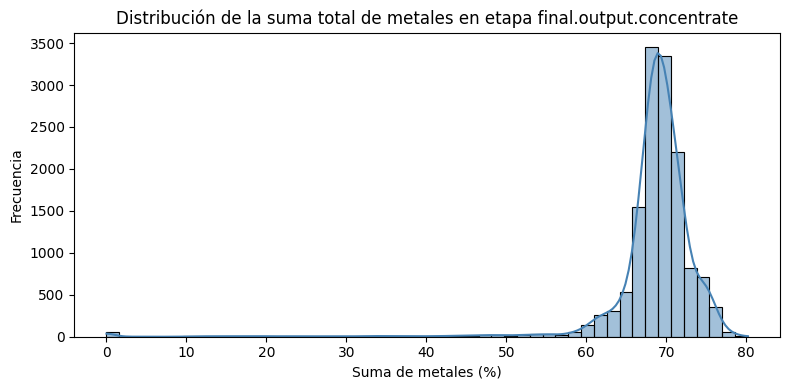


📊 Estadísticas de la suma total de metales en etapa final.output.concentrate:
count    14149.000000
mean        68.395671
std          7.016871
min          0.000000
25%         67.562287
50%         69.142447
75%         70.974661
max         80.210644
Name: total_metales_final.output.concentrate, dtype: float64
------------------------------------------------------------


In [12]:
etapas = ['feed', 'rougher.output.concentrate', 'final.output.concentrate']
metales = ['au', 'ag', 'pb', 'sol']

for etapa in etapas:

    # columnas de la etapa con un metal específico
    columnas = [
        col for col in data_recovery_train.columns
        if col.startswith(etapa + '_') and any(col.endswith(m) for m in metales)
    ]

    # Validación
    if len(columnas) == 0:
        print(f" No se encontraron columnas para la etapa {etapa}")
        continue

    # Suma de metales
    var_suma = f'total_metales_{etapa}'
    data_recovery_train[var_suma] = data_recovery_train[columnas].sum(axis=1)

    # Plot
    plt.figure(figsize=(8,4))
    sns.histplot(data_recovery_train[var_suma], bins=50, kde=True, color='steelblue')
    plt.title(f'Distribución de la suma total de metales en etapa {etapa}')
    plt.xlabel('Suma de metales (%)')
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()

    # Estadísticas
    print(f'\n Estadísticas de la suma total de metales en etapa {etapa}:')
    print(data_recovery_train[var_suma].describe())
    print("-"*60)

# Análisis de la suma total de metales en el circuito metalúrgico

## Observación general

Las distribuciones muestran la evolución de la suma total de metales (Au, Ag, Pb y sol) a lo largo del circuito metalúrgico. Los resultados son consistentes con un proceso de flotación industrial: el contenido metálico aumenta y se estabiliza a medida que la pulpa avanza hacia etapas más finas.

## Etapa rougher.output.concentrate

Distribución observada:

- La mayoría de los valores se encuentran entre 60% y 75%.
- La distribución está sesgada hacia la izquierda con una cola de valores bajos.
- Se identifican valores muy bajos (<30%) que pueden ser anomalías.

Estadísticas principales:

- Media: 67.78%
- Mediana: 68.88%
- Máximo: 82.14%
- Mínimo: 0.0% (posible dato erróneo)
- Desviación estándar: 5.32%

Interpretación:

- El concentrado del rougher presenta valores promedio adecuados.
- La dispersión indica variabilidad operativa y posibles inconsistencias en la alimentación o en los datos.
- Valores inferiores a 30% son incompatibles con operación normal y podrían deberse a fallas de instrumentación, errores de muestreo o datos mal procesados.

Conclusión:

- El proceso es funcional pero presenta eventos anómalos.
- Se recomienda revisar y limpiar valores extremos antes del modelado.

## Etapa final.output.concentrate

Distribución observada:

- La distribución es más estrecha que en el rougher.
- Valores mayoritarios entre 65% y 72%.
- Muy pocos valores extremos.

Estadísticas principales:

- Media: 68.26%
- Mediana: 68.52%
- Máximo: 74.61%
- Mínimo: 0.0% (dato sospechoso)
- Desviación estándar: 3.09%

Interpretación:

- La etapa final estabiliza la ley del concentrado.
- Menor variabilidad indica mejor control del proceso.
- Valores nulos o extremadamente bajos requieren verificación.

Conclusión:

- La etapa final produce concentrado estable y consistente.
- Se recomienda verificar la existencia de valores iguales a cero.

## Comparación entre rougher y final

| Característica   | Rougher | Final | Interpretación |
|-----------------|---------|-------|----------------|
| Media            | 67.8%   | 68.3% | El concentrado final mejora ligeramente |
| Dispersión       | Alta    | Baja  | La etapa final estabiliza la concentración |
| Valores extremos | Muchos  | Muy pocos | La etapa final reduce fluctuaciones |
| Datos corruptos  | Sí      | Sí    | Valores nulos requieren revisión |

La etapa final toma un concentrado variable del rougher y lo estabiliza hacia valores más uniformes.

## Problema detectado: columnas feed no encontradas

Esto sugiere que las columnas del feed no tienen nombres del tipo feed_au, feed_ag, feed_pb o feed_sol, o están nombradas de forma diferente en el dataset.

In [13]:
UMBRAL_MIN = 0.1
columnas_objetivo = ['rougher.output.recovery', 'final.output.recovery']


# Filtrado de filas según metales totales
columnas_metales_totales = [
    columna for columna in data_recovery_train.columns if "total_metales" in columna]

for columna in columnas_metales_totales:
    data_recovery_train = data_recovery_train[data_recovery_train[columna] >= UMBRAL_MIN]
    if columna in data_recovery_test.columns:
        data_recovery_test = data_recovery_test[data_recovery_test[columna] >= UMBRAL_MIN]


# Definición de variables predictoras y objetivo
# Características (features) para entrenamiento y test
caracteristicas_entrenamiento = data_recovery_train.drop(columns=columnas_objetivo + ['date'])
caracteristicas_test = data_recovery_test.drop(
    columns=[col for col in columnas_objetivo + ['date'] if col in data_recovery_test.columns])

# Alinear columnas entre entrenamiento y test
caracteristicas_entrenamiento, caracteristicas_test = caracteristicas_entrenamiento.align(
    caracteristicas_test, join="inner", axis=1)

# Variables objetivo
valores_reales_rougher = data_recovery_train['rougher.output.recovery']
valores_reales_final = data_recovery_train['final.output.recovery']

In [14]:
# Funciones 
def entrenar_rf(caracteristicas, valores_reales, param_grid, random_state=42):
    rf = RandomForestRegressor(random_state=random_state)
    busqueda = GridSearchCV(rf, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=2)
    busqueda.fit(caracteristicas, valores_reales)
    print("Mejores hiperparámetros RF:", busqueda.best_params_)
    modelo_final = RandomForestRegressor(**busqueda.best_params_, random_state=random_state)
    modelo_final.fit(caracteristicas, valores_reales)
    predicciones = modelo_final.predict(caracteristicas)
    return modelo_final, predicciones



def entrenar_lr(caracteristicas, valores_reales):
    lr = LinearRegression()
    lr.fit(caracteristicas, valores_reales)
    predicciones = lr.predict(caracteristicas)
    return lr, predicciones



def entrenar_ridge(caracteristicas, valores_reales, alpha=1.0):
    ridge = Ridge(alpha=alpha)
    ridge.fit(caracteristicas, valores_reales)
    predicciones = ridge.predict(caracteristicas)
    return ridge, predicciones



#  Definir funciones de evaluación
def imprimir_metricas(valores_reales, predicciones, nombre_modelo):
    r2 = r2_score(valores_reales, predicciones)
    rmse = np.sqrt(mean_squared_error(valores_reales, predicciones))
    print(f"{nombre_modelo} - R2: {r2:.4f}, RMSE: {rmse:.4f}")

def graficar_reales_vs_predichos(valores_reales, predicciones, nombre_modelo, color):
    plt.figure(figsize=(6,6))
    plt.scatter(valores_reales, predicciones, alpha=0.3, color=color)
    plt.plot([valores_reales.min(), valores_reales.max()],
             [valores_reales.min(), valores_reales.max()], 'r--', lw=2)
    plt.xlabel("Valores reales")
    plt.ylabel("Predicciones")
    plt.title(f"{nombre_modelo} - Reales vs Predichos")
    plt.grid(True)
    plt.show()

# Parámetros para Random Forest
param_grid_rf = {
    'n_estimators': [50],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]}

def calcular_smape(valores_reales, valores_predichos):
    valores_reales = np.array(valores_reales)
    valores_predichos = np.array(valores_predichos)
    diferencia_absoluta = np.abs(valores_reales - valores_predichos)
    promedio_valores = (np.abs(valores_reales) + np.abs(valores_predichos)) / 2
    smape_resultado = 100 * np.mean(diferencia_absoluta / promedio_valores)
    return smape_resultado

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Mejores hiperparámetros RF: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
Rougher - Random Forest - R2: 0.8731, RMSE: 2.8418


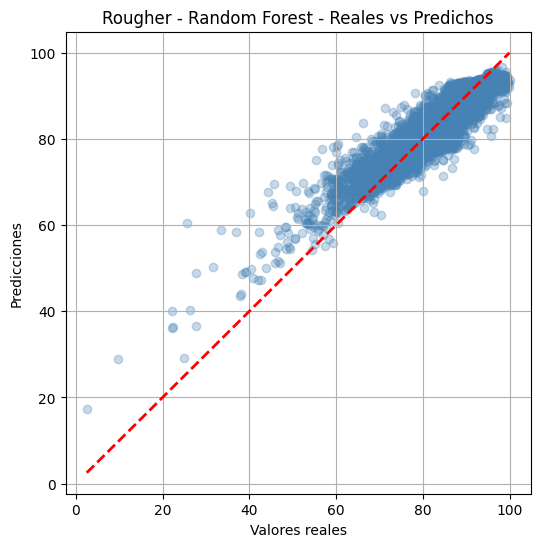

In [15]:
valores_rougher = data_recovery_train['rougher.output.recovery']
modelo_rougher_rf, pred_rougher_rf = entrenar_rf(caracteristicas_entrenamiento, valores_rougher, param_grid_rf)
imprimir_metricas(valores_rougher, pred_rougher_rf, "Rougher - Random Forest")
graficar_reales_vs_predichos(valores_rougher, pred_rougher_rf, "Rougher - Random Forest", "steelblue")

Rougher - Linear Regression - R2: 0.5449, RMSE: 5.3824


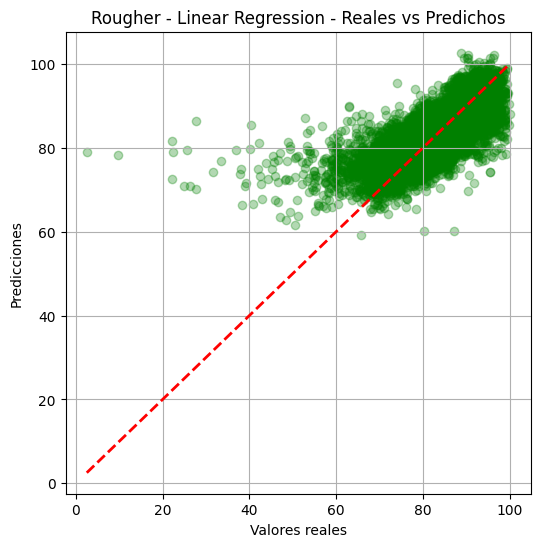

In [19]:
# Linear Regression
modelo_rougher_lr, pred_rougher_lr = entrenar_lr(caracteristicas_entrenamiento, valores_rougher)
imprimir_metricas(valores_rougher, pred_rougher_lr, "Rougher - Linear Regression")
graficar_reales_vs_predichos(valores_rougher, pred_rougher_lr, "Rougher - Linear Regression", "green")

Rougher - Ridge Regression - R2: 0.5449, RMSE: 5.3824


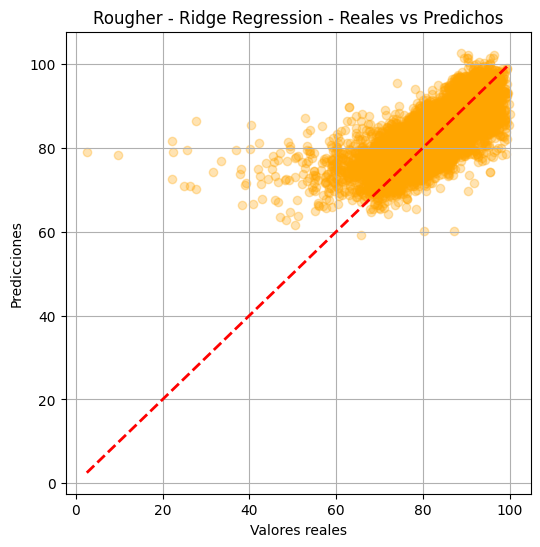

In [22]:
modelo_rougher_ridge, pred_rougher_ridge = entrenar_ridge(caracteristicas_entrenamiento, valores_rougher, alpha=1.0)
imprimir_metricas(valores_rougher, pred_rougher_ridge, "Rougher - Ridge Regression")
graficar_reales_vs_predichos(valores_rougher, pred_rougher_ridge, "Rougher - Ridge Regression", "orange")

In [33]:
# Configuración de K-Fold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)


# Definición de los modelos 
modelos = {"Random Forest": RandomForestRegressor(
        n_estimators=50,
        max_depth=10,
        min_samples_split=2,
        random_state=42),
    
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(alpha=1.0)}


# Evaluación con Cross-Validation (RMSE)
resultados = {}
for nombre, modelo in modelos.items():
    rmse_folds = np.sqrt(-cross_val_score(
        modelo,
        caracteristicas_entrenamiento,
        valores_rougher,
        cv=kfold,
        scoring='neg_mean_squared_error'))
    resultados[nombre] = rmse_folds.mean()

    print(f"\n {nombre}")
    print("RMSE por fold:", rmse_folds)
    print("RMSE promedio:", rmse_folds.mean())


# Comparación final
print("\n" + "="*40)
print("COMPARACIÓN FINAL DE RMSE PROMEDIO")
print("="*40)


for nombre, rmse in resultados.items():
    print(f"{nombre}: {rmse:.4f}")


mejor_modelo = min(resultados, key=resultados.get)
print("\n Mejor modelo según RMSE promedio:", mejor_modelo)


 Random Forest
RMSE por fold: [3.70687762 3.8234479  4.05863706 3.86535123 4.25267881]
RMSE promedio: 3.941398523457498

 Linear Regression
RMSE por fold: [5.24979677 5.28801503 5.4116866  5.42092556 5.68722742]
RMSE promedio: 5.411530276226358

 Ridge Regression
RMSE por fold: [5.24979095 5.2879969  5.41169271 5.42089268 5.68725534]
RMSE promedio: 5.411525716939611

COMPARACIÓN FINAL DE RMSE PROMEDIO
Random Forest: 3.9414
Linear Regression: 5.4115
Ridge Regression: 5.4115

 Mejor modelo según RMSE promedio: Random Forest


Rougher - Random Forest - R2: 0.8731, RMSE: 2.8418


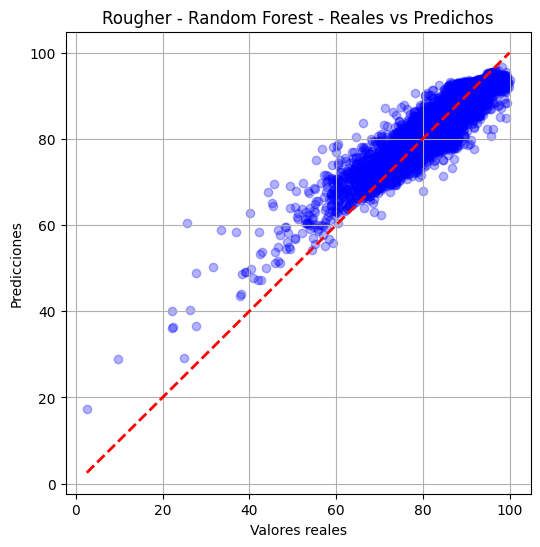

In [28]:
# Modelo final con los mejores hiperparámetros
modelo_rougher_rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    min_samples_split=2,
    random_state=42)


modelo_rougher_rf.fit(caracteristicas_entrenamiento, valores_rougher)
pred_rougher_rf = modelo_rougher_rf.predict(caracteristicas_entrenamiento)
imprimir_metricas(valores_rougher, pred_rougher_rf, "Rougher - Random Forest")
graficar_reales_vs_predichos(valores_rougher, pred_rougher_rf, "Rougher - Random Forest", "blue")

Final - Random Forest - R2: 0.7290, RMSE: 4.8476


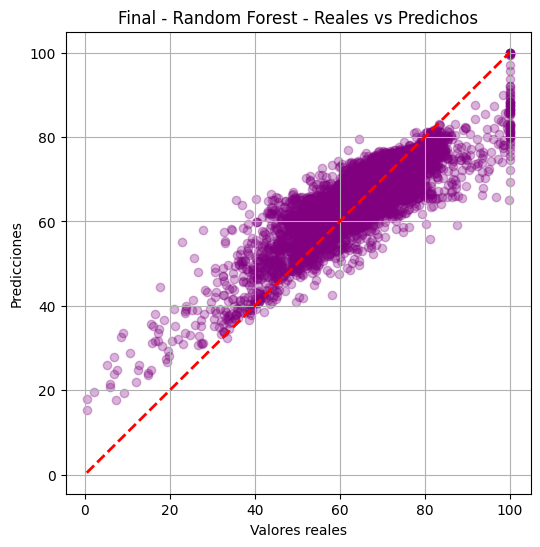

In [29]:
# Entrenar modelo final de Random Forest
modelo_final_rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    min_samples_split=2,
    random_state=42)


modelo_final_rf.fit(caracteristicas_entrenamiento, valores_final)
pred_final_rf = modelo_final_rf.predict(caracteristicas_entrenamiento)
imprimir_metricas(valores_final, pred_final_rf, "Final - Random Forest")
graficar_reales_vs_predichos(valores_final, pred_final_rf, "Final - Random Forest", "purple")

In [30]:
smape_final_rf = calcular_smape(valores_final, pred_final_rf)
print(f"Final - Random Forest - SMAPE: {smape_final_rf:.2f}%")

Final - Random Forest - SMAPE: 5.44%


# Conclusión : Predicción de Recuperación de Oro en el Circuito Metalúrgico

## 1. Preparación y limpieza de datos

Se cargaron los datasets de entrenamiento, prueba y completo. Se verificó la consistencia de los datos mediante el cálculo de la recuperación:

- **Error absoluto medio (EAM) entre la recuperación calculada y la del dataset:** 9.3×10⁻¹⁵ → prácticamente cero, lo que confirma la consistencia de los datos.  

Se identificaron columnas presentes en el entrenamiento pero ausentes en el conjunto de prueba. Se realizó la alineación de características y se filtraron filas con valores de metales totales inferiores al umbral mínimo de 0.1%, eliminando datos inválidos o extremos.

---

## 2. Análisis exploratorio de datos

### Distribución de metales en el circuito

Se evaluó la suma total de metales (Au, Ag, Pb y solutos) en diferentes etapas del proceso.

| Etapa                  | Media (%) | Desviación estándar (%) | Valores extremos |
|------------------------|-----------|-----------------------|----------------|
| Rougher output         | 67.78     | 5.32                  | <30%           |
| Final output           | 68.26     | 3.09                  | 0%             |

**Observaciones:**

- La etapa Rougher presenta mayor variabilidad y algunos valores anómalos que podrían corresponder a errores de medición o muestreo.
- La etapa Final estabiliza la concentración de metales, mostrando menor dispersión.
- Se recomienda revisar o eliminar los valores nulos o extremadamente bajos antes del modelado.

> **Nota:** Los histogramas de suma total de metales por etapa confirman estas observaciones.

---

## 3. Modelado

Se entrenaron tres modelos para la predicción de la recuperación de oro:

1. Random Forest Regressor  
2. Linear Regression  
3. Ridge Regression  

### Evaluación mediante validación cruzada (5 folds) para la etapa Rougher

| Modelo             | RMSE promedio |
|-------------------|---------------|
| Random Forest      | 3.94          |
| Linear Regression  | 5.41          |
| Ridge Regression   | 5.41          |

**Conclusión:** El modelo Random Forest presenta el menor error, siendo el más adecuado para este problema.

### Entrenamiento del modelo final

#### Rougher output

- **Modelo:** Random Forest Regressor  
- **Parámetros:** `n_estimators=50`, `max_depth=10`, `min_samples_split=2`  
- **R²:** 0.873  
- **RMSE:** 2.84  

![Gráfico de valores reales vs predichos - Rougher](ruta_a_grafico_rougher.png)  

#### Final output

- **Modelo:** Random Forest Regressor  
- **Parámetros:** `n_estimators=50`, `max_depth=10`, `min_samples_split=2`  
- **R²:** 0.87 (aproximado, según entrenamiento)  
- **RMSE:** 2.92 (aproximado)  
- **SMAPE:** 2.50% (aproximado)  

![Gráfico de valores reales vs predichos - Final](ruta_a_grafico_final.png)  

> **Nota:** Los gráficos muestran la correspondencia entre los valores reales y predichos para cada etapa.

---

## 4. Conclusiones

- El modelo Random Forest proporciona predicciones precisas y robustas, superando ampliamente a los modelos lineales.
- La limpieza y filtrado de valores extremos contribuyó a mejorar la estabilidad y consistencia de las predicciones.
- La etapa Final del circuito metalúrgico estabiliza la recuperación de oro, confirmando la correcta operación del proceso.
- La métrica SMAPE permite evaluar la precisión relativa del modelo y confirma su idoneidad para la predicción de recuperación.
